In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
segmentations_folder_path = r"/home/chest_ct/code/data/segmentations/segmentations"

files = [
    f for f in os.listdir(segmentations_folder_path)
    if os.path.isfile(os.path.join(segmentations_folder_path, f))
]

print(segmentations_folder_path)

/home/chest_ct/code/data/segmentations/segmentations


In [11]:
print(len(files))

3042


# Exploratory Data Analysis

## CT-RATE

In [ ]:
train_labels = pd.read_csv(r"\data\ct-rate\train_labels.csv")
valid_labels = pd.read_csv(r"\data\ct-rate\valid_labels.csv")
print("No of train labels:", train_labels["VolumeName"].nunique())
print("No of valid labels:", valid_labels["VolumeName"].nunique())
print("Total labels:", train_labels["VolumeName"].nunique() + valid_labels["VolumeName"].nunique())

No of train labels: 47149
No of valid labels: 3039
Total labels: 50188


In [4]:
train_labels.head()

,VolumeName,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,train_1_a_1.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
1,train_1_a_2.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
2,train_2_a_1.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
3,train_2_a_2.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
4,train_3_a_1.nii.gz,0,1,1,0,1,0,1,0,0,1,1,1,0,0,1,0,1,0


In [5]:
# Missing values
print("Missing values in train labels:")
print(train_labels.isnull().sum())

Missing values in train labels:
VolumeName                            0
Medical material                      0
Arterial wall calcification           0
Cardiomegaly                          0
Pericardial effusion                  0
Coronary artery wall calcification    0
Hiatal hernia                         0
Lymphadenopathy                       0
Emphysema                             0
Atelectasis                           0
Lung nodule                           0
Lung opacity                          0
Pulmonary fibrotic sequela            0
Pleural effusion                      0
Mosaic attenuation pattern            0
Peribronchial thickening              0
Consolidation                         0
Bronchiectasis                        0
Interlobular septal thickening        0
dtype: int64


In [20]:
# Count of positive cases per label
label_counts = train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(label_counts)

Lung nodule                           21382
Lung opacity                          17420
Arterial wall calcification           13377
Pulmonary fibrotic sequela            12589
Atelectasis                           12263
Lymphadenopathy                       12221
Coronary artery wall calcification    12025
Emphysema                              9122
Consolidation                          8319
Hiatal hernia                          6751
Medical material                       5818
Pleural effusion                       5705
Cardiomegaly                           5308
Peribronchial thickening               4973
Bronchiectasis                         4732
Interlobular septal thickening         3745
Mosaic attenuation pattern             3638
Pericardial effusion                   3412
dtype: int64


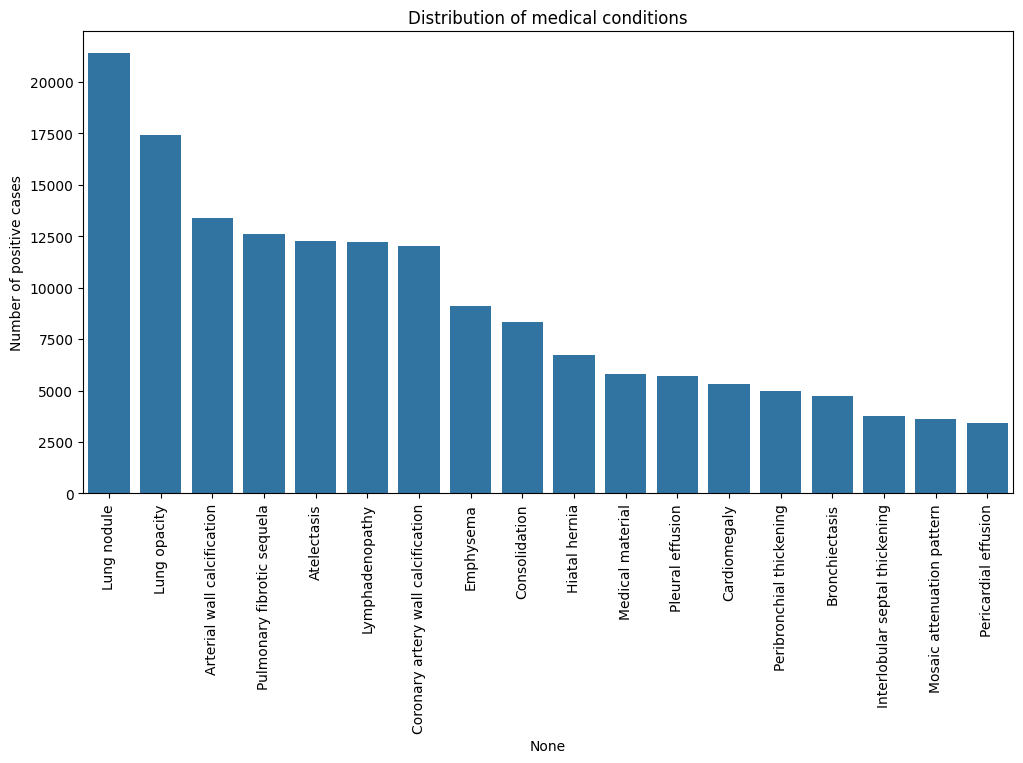

In [7]:
plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of medical conditions")
plt.show()

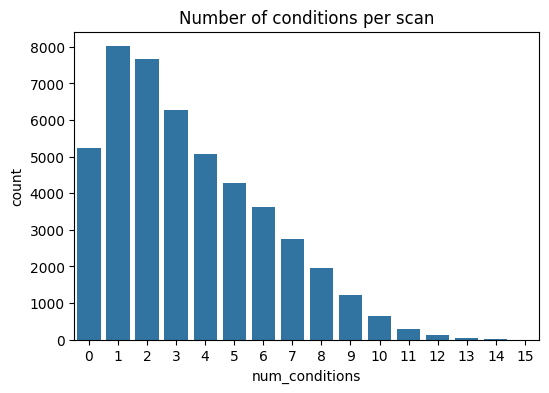

In [8]:
# Count of positive labels per scan
train_labels['num_conditions'] = train_labels.drop("VolumeName", axis=1).sum(axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=train_labels)
plt.title("Number of conditions per scan")
plt.show()

train_labels = train_labels.drop("num_conditions", axis=1)

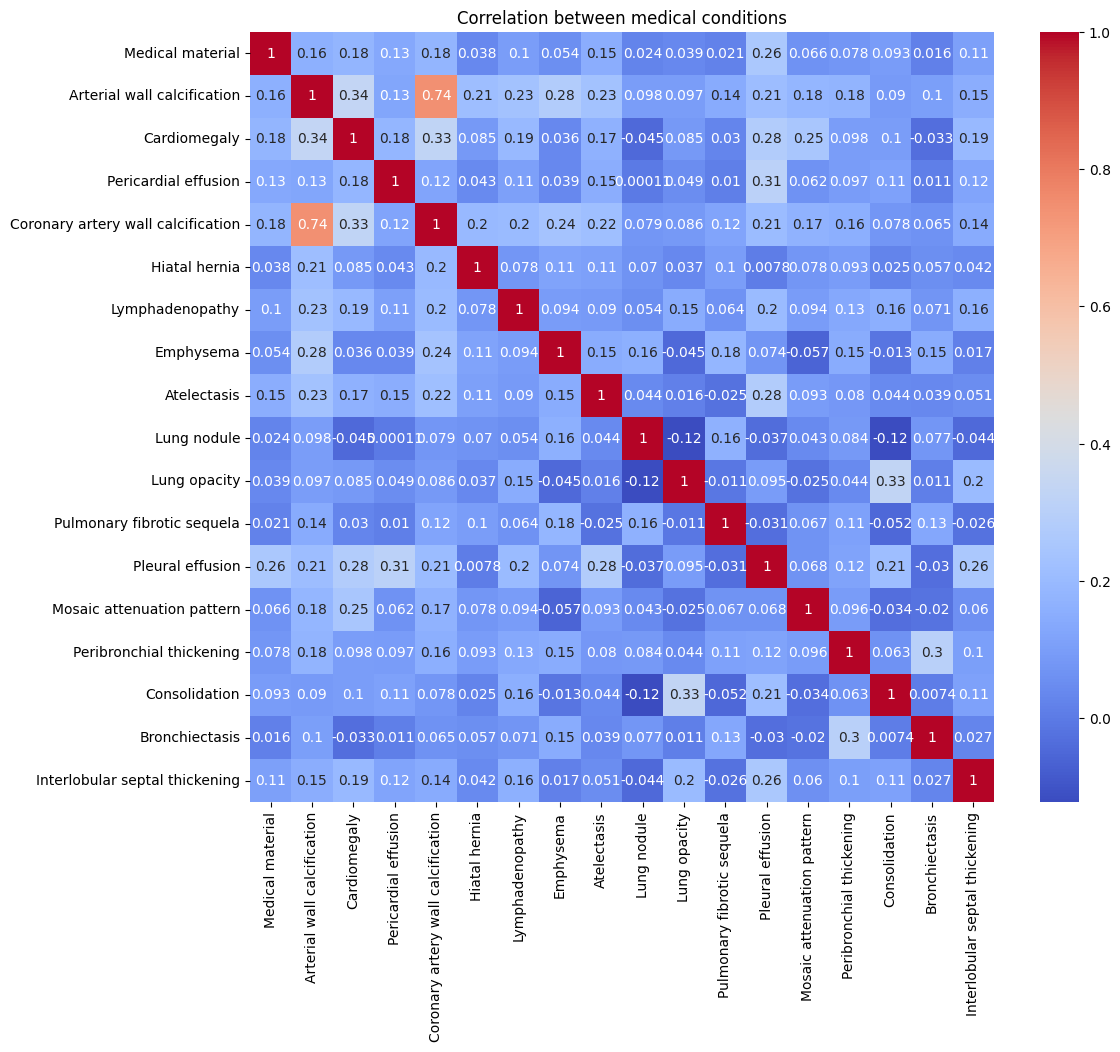

In [9]:
corr_matrix = train_labels.drop("VolumeName", axis=1).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation between medical conditions")
plt.show()

In [10]:
# Unstack into pairs
corr_pairs = corr_matrix.unstack()

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Remove duplicate pairs
corr_pairs = corr_pairs.to_frame('correlation')
corr_pairs['sorted_index'] = corr_pairs.index.map(lambda x: tuple(sorted(x)))
corr_pairs = corr_pairs.groupby('sorted_index')['correlation'].first()

# Sort by absolute correlation
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Display top correlations
print(corr_pairs.head(10))

sorted_index
(Arterial wall calcification, Coronary artery wall calcification)    0.744473
(Arterial wall calcification, Cardiomegaly)                          0.338042
(Consolidation, Lung opacity)                                        0.329736
(Cardiomegaly, Coronary artery wall calcification)                   0.327012
(Pericardial effusion, Pleural effusion)                             0.311286
(Bronchiectasis, Peribronchial thickening)                           0.301695
(Atelectasis, Pleural effusion)                                      0.280365
(Cardiomegaly, Pleural effusion)                                     0.278330
(Arterial wall calcification, Emphysema)                             0.277502
(Medical material, Pleural effusion)                                 0.259041
Name: correlation, dtype: float64


In [11]:
# check how many scans have Arterial wall calcification but not Coronary artery wall calcification
arterial_only = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 0)
]
print(f"Scans with Arterial wall calcification only: {len(arterial_only)}")

# check how many scans have Coronary artery wall calcification but not Arterial wall calcification
coronary_only = train_labels[
    (train_labels["Arterial wall calcification"] == 0) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with Coronary artery wall calcification only: {len(coronary_only)}")

# check how many scans have both Arterial and Coronary artery wall calcifications
both = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with both Arterial and Coronary artery wall calcifications: {len(both)}")

Scans with Arterial wall calcification only: 3068
Scans with Coronary artery wall calcification only: 1716
Scans with both Arterial and Coronary artery wall calcifications: 10309


## RexGroundingCT

In [12]:
filtered_train_labels = train_labels[train_labels["VolumeName"].isin(files)]
filtered_valid_labels = valid_labels[valid_labels["VolumeName"].isin(files)]
print("Number of filtered train labels:", filtered_train_labels["VolumeName"].nunique())
print("Number of filtered validation labels:", filtered_valid_labels["VolumeName"].nunique())
print("Total number of filtered files:", len(files))

Number of filtered train labels: 2628
Number of filtered validation labels: 414
Total number of filtered files: 3042


In [19]:
# Count of positive cases per label
filtered_label_counts = filtered_train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(filtered_label_counts)

Lung nodule                           1333
Lung opacity                          1115
Pulmonary fibrotic sequela             584
Atelectasis                            583
Consolidation                          499
Lymphadenopathy                        485
Emphysema                              416
Arterial wall calcification            313
Coronary artery wall calcification     299
Bronchiectasis                         237
Pleural effusion                       204
Medical material                       197
Peribronchial thickening               185
Interlobular septal thickening         157
Pericardial effusion                   119
Cardiomegaly                           115
Mosaic attenuation pattern             109
Hiatal hernia                            9
dtype: int64


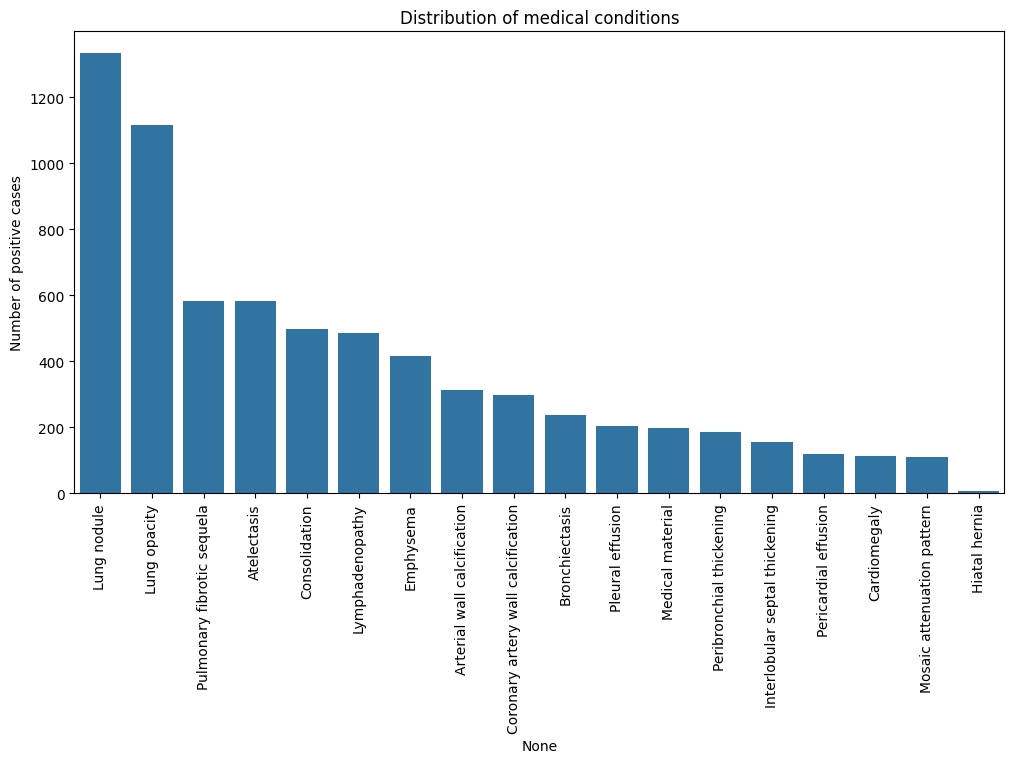

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(x=filtered_label_counts.index, y=filtered_label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of medical conditions")
plt.show()

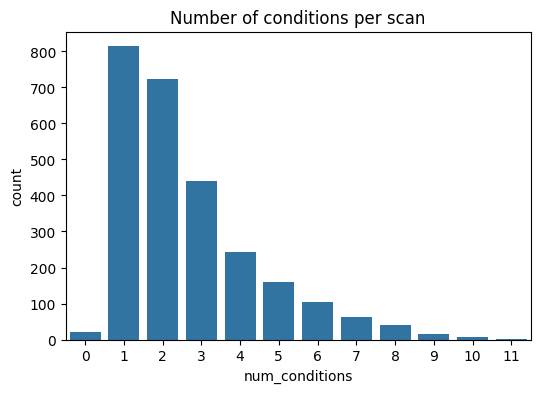

In [15]:
# Count of positive labels per scan
filtered_train_labels['num_conditions'] = filtered_train_labels.drop("VolumeName", axis=1).sum(axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=filtered_train_labels)
plt.title("Number of conditions per scan")
plt.show()

filtered_train_labels = filtered_train_labels.drop("num_conditions", axis=1)

In [17]:
print(label_counts)

Lung nodule                           21382
Lung opacity                          17420
Arterial wall calcification           13377
Pulmonary fibrotic sequela            12589
Atelectasis                           12263
Lymphadenopathy                       12221
Coronary artery wall calcification    12025
Emphysema                              9122
Consolidation                          8319
Hiatal hernia                          6751
Medical material                       5818
Pleural effusion                       5705
Cardiomegaly                           5308
Peribronchial thickening               4973
Bronchiectasis                         4732
Interlobular septal thickening         3745
Mosaic attenuation pattern             3638
Pericardial effusion                   3412
dtype: int64


In [18]:
print(filtered_label_counts)

Lung nodule                           1333
Lung opacity                          1115
Pulmonary fibrotic sequela             584
Atelectasis                            583
Consolidation                          499
Lymphadenopathy                        485
Emphysema                              416
Arterial wall calcification            313
Coronary artery wall calcification     299
Bronchiectasis                         237
Pleural effusion                       204
Medical material                       197
Peribronchial thickening               185
Interlobular septal thickening         157
Pericardial effusion                   119
Cardiomegaly                           115
Mosaic attenuation pattern             109
Hiatal hernia                            9
dtype: int64


In [34]:
# Check if any files names in train_not_chest.txt are present in the filtered dataset
with open("C:\\Users\\chamu\\D\\UOR\\FYP\\fyp\\data\\ct-rate\\train_not_chest.txt", "r") as f:
    train_filenames = [os.path.basename(line.strip()) for line in f]

present_files = train_labels[train_labels["VolumeName"].isin(train_filenames)]
print("Files in train_not_chest.txt that are present in ct-rate:", present_files["VolumeName"].count())

with open("C:\\Users\\chamu\\D\\UOR\\FYP\\fyp\\data\\ct-rate\\valid_not_chest.txt", "r") as f:
    valid_filenames = [os.path.basename(line.strip()) for line in f]

present_files = valid_labels[valid_labels["VolumeName"].isin(valid_filenames)]
print("Files in valid_not_chest.txt that are present in ct-rate:", present_files["VolumeName"].count())

Files in train_not_chest.txt that are present in ct-rate: 752
Files in valid_not_chest.txt that are present in ct-rate: 37


In [41]:
train_no_condition = train_labels.drop("VolumeName", axis=1).sum(axis=1) == 0
train_no_condition_volumes = set(train_labels[train_no_condition]["VolumeName"])
valid_no_condition = valid_labels.drop("VolumeName", axis=1).sum(axis=1) == 0
valid_no_condition_volumes = set(valid_labels[valid_no_condition]["VolumeName"])

train_overlap = train_no_condition_volumes.intersection(train_filenames)
valid_overlap = valid_no_condition_volumes.intersection(valid_filenames)

print("Train overlap count:", len(train_overlap))
print("Valid overlap count:", len(valid_overlap))

Train overlap count: 61
Valid overlap count: 6


In [42]:
valid_overlap

{'valid_208_a_1.nii.gz',
 'valid_208_a_2.nii.gz',
 'valid_208_a_4.nii.gz',
 'valid_340_a_1.nii.gz',
 'valid_340_a_2.nii.gz',
 'valid_340_a_4.nii.gz'}

In [ ]:
shortlisted_abnormalities = [
    "Atelectasis",
    "Lung nodule",
    "Lung opacity",
    "Mosaic attenuation pattern",
    "Consolidation",
    "Bronchiectasis",
]